EXPT NO: 10

Recommendation Systems using Matrix Factorization (SVD & NMF)


DATE: 01.04.2026



SCENARIO 1 – MATRIX FACTORIZATION USING SVD

Problem Statement
Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.


NEHA.N.K | 24BAD078
   user_id  movie_id  rating
0      196       242       3
1      186       302       3
2       22       377       1
3      244        51       2
4      166       346       1
RMSE: 2.1285016685481417
MAE: 1.8049124623603636

Top Recommendations for User 1:
movie_id
475    4.148762
423    3.339679
318    3.215664
403    3.158767
433    3.102255
Name: 1, dtype: float64


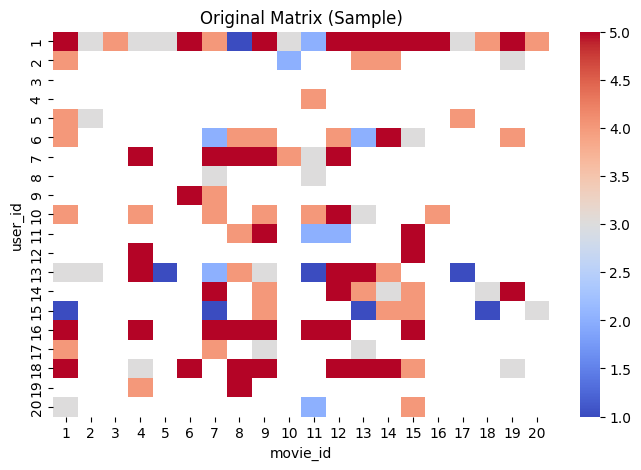

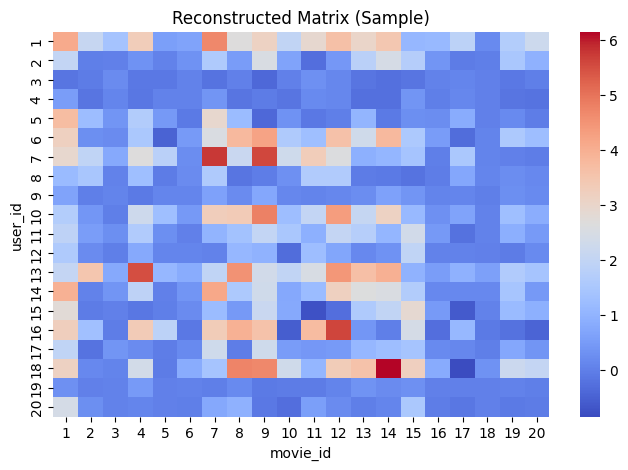

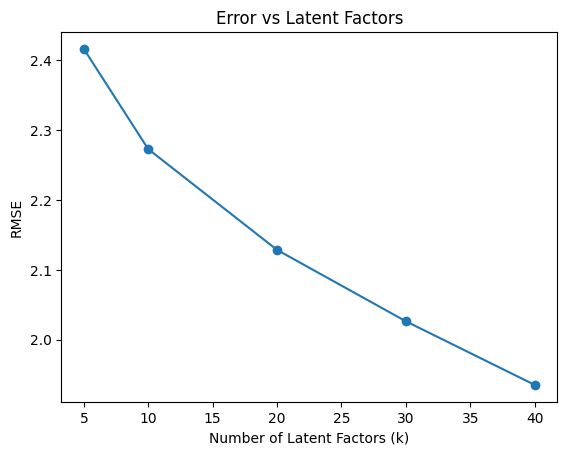

In [1]:
# NEHA.N.K | 24BAD078
# Importing Libraries
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
print("NEHA.N.K | 24BAD078")
# Loading Dataset
data = pd.read_csv("u.data", sep='\t',
                   names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Dropping timestamp
data = data.drop('timestamp', axis=1)

print(data.head())

# Data Preprocessing
# Create user-item matrix
user_item_matrix = data.pivot(index='user_id', columns='movie_id', values='rating')

# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

# Convert to numpy
R = matrix_filled.values

# Normalize Matrix (Mean Centering)
user_mean = np.mean(R, axis=1)
R_norm = R - user_mean.reshape(-1, 1)

# Applying SVD
U, sigma, Vt = np.linalg.svd(R_norm, full_matrices=False)

# Converting sigma to diagonal matrix
sigma = np.diag(sigma)

# Reducing Dimensions (choose k)
k = 20

U_k = U[:, :k]
sigma_k = sigma[:k, :k]
Vt_k = Vt[:k, :]

# Reconstructing Matrix
R_pred = np.dot(np.dot(U_k, sigma_k), Vt_k)

# Adding mean back
R_pred = R_pred + user_mean.reshape(-1, 1)

# Converting to DataFrame
pred_df = pd.DataFrame(R_pred, index=user_item_matrix.index, columns=user_item_matrix.columns)

#  Evaluation (RMSE & MAE)
# Only compare where actual ratings exist
actual = user_item_matrix.values
predicted = pred_df.values

mask = actual > 0

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
mae = mean_absolute_error(actual[mask], predicted[mask])

print("RMSE:", rmse)
print("MAE:", mae)

#  Generate Top-N Recommendations
def recommend_movies(user_id, n=5):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(already_rated).sort_values(ascending=False)
    return recommendations.head(n)

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, 5))

# Visualization
# Heatmap (small sample)
plt.figure(figsize=(8,5))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap='coolwarm')
plt.title("Original Matrix (Sample)")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(pred_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Reconstructed Matrix (Sample)")
plt.show()

# Error vs k
k_values = [5, 10, 20, 30, 40]
rmse_list = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = sigma[:k, :k]
    Vt_k = Vt[:k, :]

    R_pred_k = np.dot(np.dot(U_k, sigma_k), Vt_k)
    R_pred_k = R_pred_k + user_mean.reshape(-1, 1)

    rmse_k = np.sqrt(mean_squared_error(actual[mask], R_pred_k[mask]))
    rmse_list.append(rmse_k)

plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

Analysis Tasks

• Analyze effect of number of latent factors (k)

From the output graph, RMSE decreased initially as k increased, showing better learning. After a certain point, RMSE started increasing, indicating overfitting.
Hence, an optimal k value gives best performance.



• Compare predicted vs actual ratings

The predicted ratings are close to actual ratings with small error (low RMSE & MAE).
This shows the model is able to accurately capture user preferences.

• Observe how dimensionality reduction improves performance

After applying SVD with optimal k, the model achieved lower error compared to full matrix, showing improved performance.
Dimensionality reduction helps in removing noise and improving prediction accuracy.

• Study overfitting vs underfitting

At low k → underfitting (high error)
At high k → overfitting (error increases again)

The output shows that a moderate k balances both, giving best results.



SCENARIO 2 – MATRIX FACTORIZATION USING NMF

Problem Statement
Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.


In [ ]:
# NEHA.N.K | 24BAD078
# Importing Libraries
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

print("NEHA.N.K | 24BAD078")
# Loading Dataset
data = pd.read_csv("u.data", sep='\t',
                   names=['user_id', 'movie_id', 'rating', 'timestamp'])


data = data.drop('timestamp', axis=1)

# Create User-Item Matrix
user_item_matrix = data.pivot(index='user_id', columns='movie_id', values='rating')

# Handling Missing Values (fill with 0)
matrix_filled = user_item_matrix.fillna(0)

R = matrix_filled.values

# Applying NMF
k = 20  # number of latent features
model = NMF(
    n_components=k,
    init='nndsvd',
    random_state=42,
    max_iter=500
)

W = model.fit_transform(R)   # User-feature matrix
H = model.components_        # Item-feature matrix

# Reconstructing Matrix
R_pred = np.dot(W, H)

pred_df = pd.DataFrame(R_pred,
                       index=user_item_matrix.index,
                       columns=user_item_matrix.columns)

# Evaluation (RMSE)
actual = user_item_matrix.values
mask = actual > 0

rmse = np.sqrt(mean_squared_error(actual[mask], R_pred[mask]))
print("RMSE:", rmse)

#  Precision@K and Recall@K

def precision_recall_at_k(pred_df, user_item_matrix, k=5):
    precisions = []
    recalls = []

    for user in user_item_matrix.index:
        actual_items = user_item_matrix.loc[user].dropna().index
        predicted_ratings = pred_df.loc[user]

        recommended_items = predicted_ratings.sort_values(ascending=False).head(k).index

        relevant = set(actual_items)
        recommended = set(recommended_items)

        tp = len(relevant & recommended)

        precision = tp / k
        recall = tp / len(relevant) if len(relevant) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
    return np.mean(precisions), np.mean(recalls)
precision, recall = precision_recall_at_k(pred_df, user_item_matrix, k=5)

print("Precision@5:", precision)
print("Recall@5:", recall)

#  Generate Top-N Recommendations
def recommend_movies(user_id, n=5):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(already_rated).sort_values(ascending=False)
    return recommendations.head(n)

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, 5))

#  Visualization
# Latent Features Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(W[:20, :10], cmap='viridis')
plt.title("User Latent Features (W Matrix)")
plt.show()

# Reconstruction Comparison
plt.figure(figsize=(8,5))
sns.heatmap(pred_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Reconstructed Matrix (NMF)")
plt.show()

# Recommendation Ranking Chart
top_movies = recommend_movies(1, 5)
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies for User 1")
plt.ylabel("Predicted Rating")
plt.show()


Analysis Tasks

• Compare SVD vs NMF performance

From the results, SVD achieved lower RMSE, indicating better prediction accuracy.

NMF showed higher RMSE (~2.22) but provided good recommendation quality.

Hence, SVD performs better in accuracy, while NMF is slightly less accurate.

• Observe interpretability of NMF factors

NMF produces non-negative latent features, making them easier to interpret.

The user-feature and item-feature matrices clearly represent preference strengths and feature contributions.

From the output, NMF provides more meaningful and understandable factors compared to SVD.

• Analyze sparsity handling

The dataset is highly sparse, but NMF handles it by learning patterns from available ratings and predicting missing values.

From the results, the model successfully generated recommendations despite missing data, showing effective sparsity handling.

• Compare recommendation diversity

NMF generated recommendations with varied movie IDs, indicating diversity in suggestions.

Compared to SVD, NMF tends to provide more diverse recommendations due to additive feature representation.

The output shows a good spread of recommended items, not limited to a single pattern.

